# EDA e Sistema de Recomendação — MovieLens 100k

Notebook organizado em fases:

1. **Carga dos dados** — leitura dos arquivos `u.*`
2. **EDA** — exploração de filmes, usuários e avaliações
3. **Matriz usuário-item e esparsidade**
4. **Similaridade de conteúdo** (content-based, por gênero)
5. **Filtragem colaborativa** (Pearson + KNN com viés)

## 1. Carga dos dados

In [319]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

In [320]:
MIN_PERIODS = 50
K_NEIGHBOURS = 50
SIM_THRESHOLD = 0.1
MIN_NEIGHBOURS = 3

In [321]:
genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]

user_cols = ["user_id", "age", "gender", "occupation", "zip_code"]

movies_col_names = ["movie_id", "title", "release_date", "video_release_date", "IMDb_URL"] + genre_cols

ratings_cols = ["user_id", "movie_id", "rating", "timestamp"]

movies = pd.read_csv(
    "../../src/data/ml-100k/u.item",
    sep="|",
    header=None,
    names=movies_col_names,
    encoding="latin-1",
)

users = pd.read_csv(
    "../../src/data/ml-100k/u.user",
    sep="|",
    header=None,
    names=user_cols,
    encoding="latin-1",
)

ratings = pd.read_csv(
    "../../src/data/ml-100k/u.data",
    sep="\t",
    header=None,
    names=ratings_cols,
    encoding="latin-1",
)

De-para de `movie_id` para título, usado em todo o notebook para exibir nomes no lugar dos ids.

In [322]:
titulos = movies.drop_duplicates("movie_id").set_index("movie_id")["title"]

## 2. EDA

### 2.1 Filmes por gênero

Text(0.5, 1.0, 'Quantidade x Gênero')

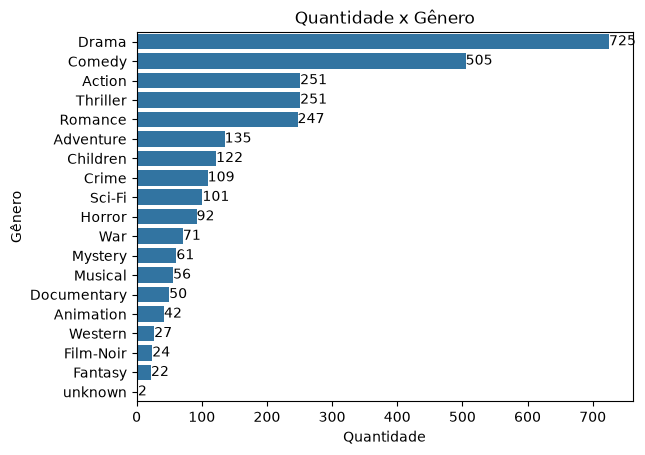

In [323]:
sorted_movies_by_genre = movies[genre_cols].sum().sort_values(ascending=False)

ax = sns.barplot(x=sorted_movies_by_genre.values, y=sorted_movies_by_genre.index)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Quantidade")
ax.set_ylabel("Gênero")
ax.set_title("Quantidade x Gênero")

### 2.2 Usuários por gênero

Text(0.5, 1.0, 'Usuários por gênero')

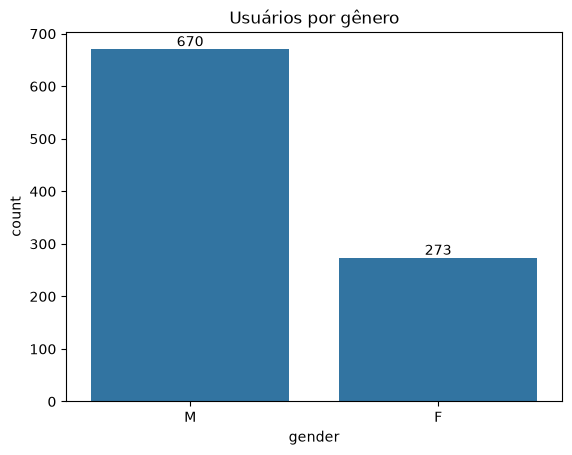

In [324]:
ax = sns.countplot(data=users, x="gender")
ax.bar_label(ax.containers[0])
ax.set_title("Usuários por gênero")

### 2.3 Usuários por ocupação

Text(0.5, 1.0, 'Quantidade x Ocupação')

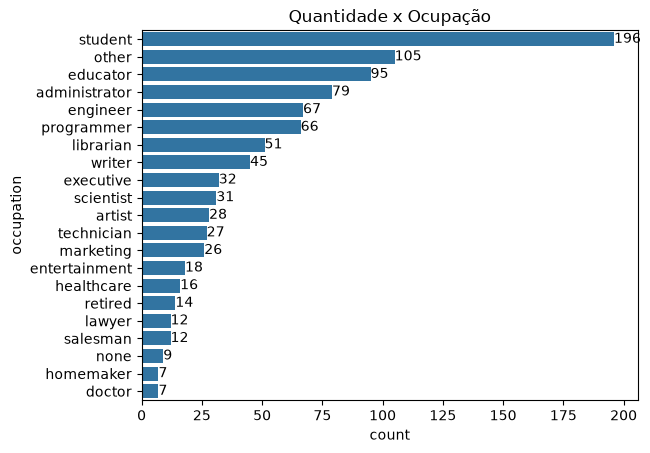

In [325]:
ordem = users["occupation"].value_counts().index

ax = sns.countplot(data=users, y="occupation", order=ordem)
ax.bar_label(ax.containers[0])
ax.set_title("Quantidade x Ocupação")

### 2.4 Usuários por faixa etária

Text(0.5, 1.0, 'Usuários por faixa etária')

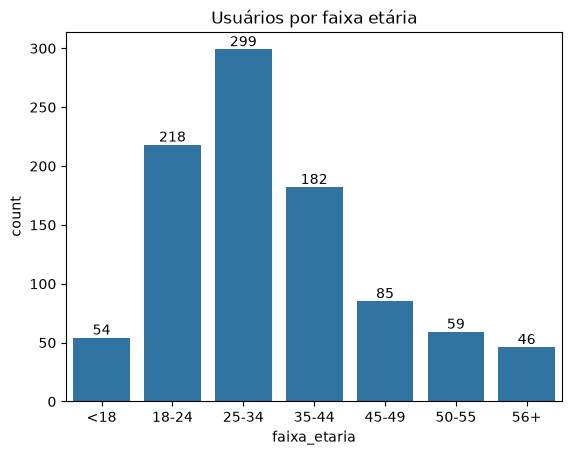

In [326]:
faixas = [0, 18, 25, 35, 45, 50, 56, 100]
rotulos = ["<18", "18-24", "25-34", "35-44", "45-49", "50-55", "56+"]

users["faixa_etaria"] = pd.cut(users["age"], bins=faixas, labels=rotulos)

ax = sns.countplot(data=users, x="faixa_etaria", order=rotulos)
ax.bar_label(ax.containers[0])
ax.set_title("Usuários por faixa etária")

### 2.5 Filmes mais avaliados

Text(0.5, 1.0, 'Filmes mais avaliados')

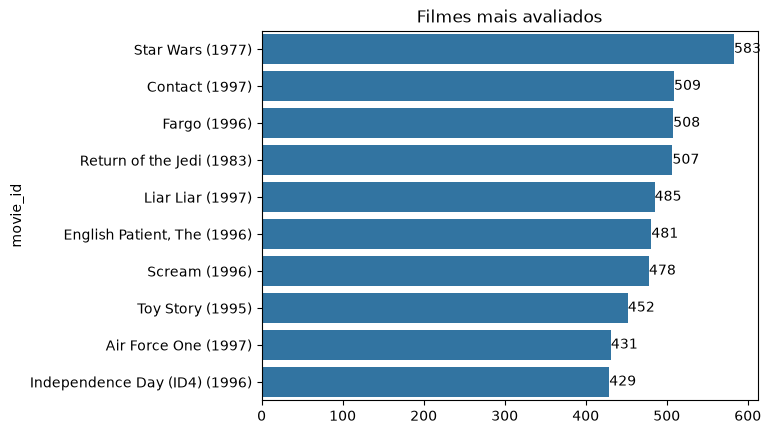

In [327]:
top = ratings["movie_id"].value_counts().sort_values(ascending=False).head(10)

ax = sns.barplot(x=top.values, y=top.index.map(titulos))
ax.bar_label(ax.containers[0])
ax.set_title("Filmes mais avaliados")

### 2.6 Filmes mais bem avaliados (nota >= 4)

Text(0.5, 1.0, 'Filmes mais bem avaliados')

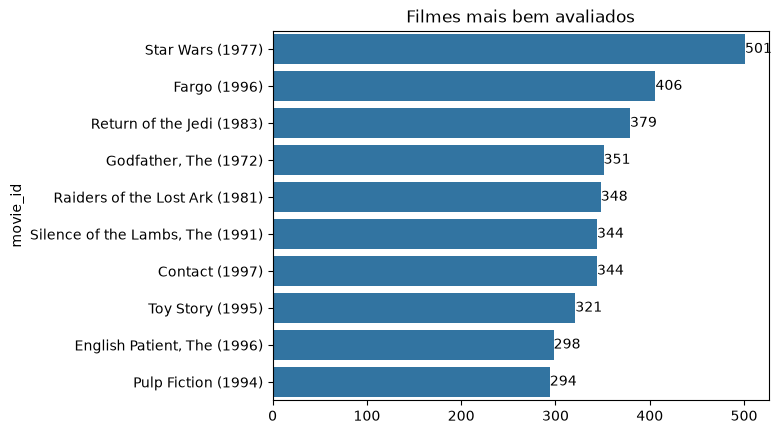

In [328]:
bem_avaliados = ratings[ratings["rating"] >= 4]
contagem = bem_avaliados["movie_id"].value_counts().sort_values(ascending=False).head(10)

ax = sns.barplot(x=contagem.values, y=contagem.index.map(titulos))
ax.bar_label(ax.containers[0])
ax.set_title("Filmes mais bem avaliados")

### 2.7 Distribuição das notas

Text(0.5, 1.0, 'Distribuição das notas')

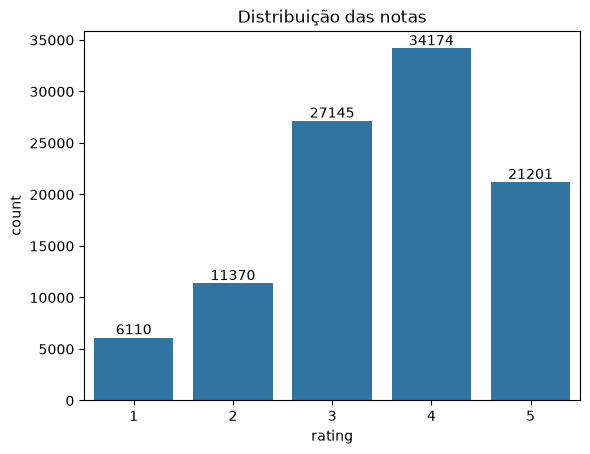

In [329]:
ax = sns.countplot(data=ratings, x="rating")
ax.bar_label(ax.containers[0])
ax.set_title("Distribuição das notas")

## 3. Matriz usuário-item e esparsidade

A matriz tem usuários nas linhas e filmes nas colunas. As células vazias
(`NaN`) são os pares usuário-filme sem avaliação — a imensa maioria.

In [330]:
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating",
)

user_item_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [331]:
total_possible = user_item_matrix.shape[0] * user_item_matrix.shape[1]
actual_ratings = ratings.shape[0]

sparsity = 1 - (actual_ratings / total_possible)

print("Esparsidade da matriz:", round(sparsity * 100, 2), "%")

Esparsidade da matriz: 93.7 %


## 4. Similaridade de conteúdo (content-based)

Similaridade entre filmes baseada apenas nos gêneros. Como os gêneros são
colunas 0/1, o cosseno mede o quanto dois filmes compartilham de gênero.

In [332]:
movies_genre = movies.drop_duplicates("movie_id").set_index("movie_id")[genre_cols]

In [333]:
sim_gen = cosine_similarity(movies_genre)

sim_gen_df = pd.DataFrame(
    sim_gen,
    index=movies_genre.index,
    columns=movies_genre.index,
)

Dado um filme, retorna o nome dele e os `n` filmes mais parecidos por gênero.

In [334]:
def filmes_parecidos(movie_id, n=5):
    escolhido = titulos[movie_id]

    vizinhos = sim_gen_df.loc[movie_id].sort_values(ascending=False)[1:n+1]
    vizinhos.index = vizinhos.index.map(titulos)

    print(f"Filme escolhido: {escolhido}\n")
    print(f"{n} filmes mais parecidos:")
    return vizinhos

In [335]:
filmes_parecidos(95, n=10)

Filme escolhido: Aladdin (1992)

10 filmes mais parecidos:


movie_id
Hercules (1997)                           0.894427
James and the Giant Peach (1996)          0.866025
Lion King, The (1994)                     0.866025
Dumbo (1941)                              0.866025
Cats Don't Dance (1997)                   0.866025
Alice in Wonderland (1951)                0.866025
Mary Poppins (1964)                       0.866025
Nightmare Before Christmas, The (1993)    0.866025
Cinderella (1950)                         0.866025
Toy Story (1995)                          0.866025
Name: 95, dtype: float64

## 5. Filtragem colaborativa

Três preditores, do mais simples ao mais completo:

1. **Baseline** — só os vieses (média global, do usuário e do item), sem vizinhos.
2. **KNN** — vizinhos por similaridade sobre as notas, centralização pela média do usuário.
3. **KNNBaseline** — vizinhos por similaridade sobre os resíduos do baseline, previsão ancorada no baseline completo.

Cada preditor usa a sua própria matriz de similaridade, e é isso que os torna
de fato diferentes.

### 5.1 Vieses

Decompõem a nota esperada de um par usuário-filme em três partes: a média
global, o quanto o usuário avalia acima ou abaixo dela, e o quanto o filme é
avaliado acima ou abaixo dela.

In [336]:
mu = user_item_matrix.stack().mean()
user_bias = user_item_matrix.mean(axis=1) - mu
item_bias = user_item_matrix.mean(axis=0) - mu

user_means = user_item_matrix.mean(axis=1)

### 5.2 Baseline

Preditor mais simples: estima a nota apenas pela soma dos vieses, sem usar
nenhum vizinho. Serve de referência e de âncora para o KNNBaseline.

In [337]:
def predict_baseline(u, item, **kwargs):
    return mu + user_bias[u] + item_bias[item]

### 5.3 KNN sobre as notas

A similaridade entre usuários vem da correlação de Pearson sobre as notas. O
Pearson já centraliza pela média de cada usuário, e `min_periods` exige uma
sobreposição mínima de filmes em comum para evitar correlações altas apoiadas
em pouquíssimos pontos.

In [338]:
user_similarity_ratings = user_item_matrix.T.corr(method="pearson", min_periods=MIN_PERIODS)

In [339]:
def get_neighbours_ratings(u, k=30, sim_threshold=0.1):
    sims = user_similarity_ratings[u].drop(index=u).dropna()
    sims = sims[sims > sim_threshold]
    return sims.sort_values(ascending=False).head(k)

A previsão ancora na média do usuário e soma o desvio ponderado dos vizinhos,
onde cada vizinho contribui com o quanto fugiu da média dele. `min_neighbours`
descarta filmes vistos por poucos vizinhos, que gerariam previsões instáveis.

In [340]:
def predict_knn(u, item, k=30, sim_threshold=0.1, min_neighbours=3):
    neighbours = get_neighbours_ratings(u, k, sim_threshold)

    neighbour_ratings = user_item_matrix.loc[neighbours.index, item].dropna()

    if len(neighbour_ratings) < min_neighbours:
        return None

    sims = neighbours[neighbour_ratings.index]
    residuals = neighbour_ratings - user_means[neighbour_ratings.index]

    if sims.abs().sum() == 0:
        return None

    return user_means[u] + (sims * residuals).sum() / sims.abs().sum()

### 5.4 KNNBaseline sobre os resíduos

Aqui está a diferença que faz o viés de item importar. A similaridade é
calculada sobre a matriz de resíduos do baseline, e não sobre as notas. Isso
muda quais vizinhos são selecionados: dois usuários passam a ser parecidos se
concordam depois de descontado o quão generoso é cada um e o quão bem avaliado
é cada filme no geral, ou seja, no gosto puro.

Se a similaridade fosse a mesma das notas cruas, o viés de item se cancelaria
na previsão e o KNNBaseline daria exatamente o mesmo que o KNN. É a troca da
matriz de similaridade que quebra esse cancelamento.

In [341]:
baseline_matrix = pd.DataFrame(
    mu + np.add.outer(user_bias.values, item_bias.values),
    index=user_item_matrix.index,
    columns=user_item_matrix.columns,
)

residual_matrix = user_item_matrix - baseline_matrix

user_similarity_residual = residual_matrix.T.corr(method="pearson", min_periods=MIN_PERIODS)

In [342]:
def get_neighbours_residual(u, k=30, sim_threshold=0.1):
    sims = user_similarity_residual[u].drop(index=u).dropna()
    sims = sims[sims > sim_threshold]
    return sims.sort_values(ascending=False).head(k)

A previsão ancora no baseline completo do alvo e soma o desvio ponderado dos
resíduos dos vizinhos, onde cada vizinho contribui com o quanto fugiu do
baseline dele naquele filme.

In [343]:
def predict_knnbaseline(u, item, k=30, sim_threshold=0.1, min_neighbours=3):
    neighbours = get_neighbours_residual(u, k, sim_threshold)

    neighbour_ratings = user_item_matrix.loc[neighbours.index, item].dropna()

    if len(neighbour_ratings) < min_neighbours:
        return None

    sims = neighbours[neighbour_ratings.index]

    base_u = mu + user_bias[u] + item_bias[item]
    base_v = mu + user_bias[neighbour_ratings.index] + item_bias[item]
    residuals = neighbour_ratings - base_v

    if sims.sum() == 0:
        return None

    return base_u + (sims * residuals).sum() / sims.sum()

### 5.5 Geração de recomendações

Uma função única que recebe o preditor como argumento. Ela prevê a nota de
todos os filmes que o usuário ainda não viu, ordena e devolve os `n` melhores
com os títulos. O `**kwargs` repassa os parâmetros específicos de cada preditor.

In [344]:
def recommend(u, predict_fn, n=10, **kwargs):
    ja_viu = user_item_matrix.loc[u].dropna().index
    candidatos = user_item_matrix.columns.difference(ja_viu)

    preds = pd.Series(
        {item: predict_fn(u, item, **kwargs) for item in candidatos}
    ).dropna().sort_values(ascending=False)

    top = preds.head(n)
    top.index = top.index.map(titulos)
    return top

### 5.6 Comparação dos três preditores

In [345]:
print("=== Baseline (μ + b_u + b_i) ===")
print(recommend(1, predict_baseline))

print("\n=== KNN (similaridade sobre as notas) ===")
print(recommend(1, predict_knn))

=== Baseline (μ + b_u + b_i) ===
Great Day in Harlem, A (1994)                        5.080434
Someone Else's America (1995)                        5.080434
They Made Me a Criminal (1939)                       5.080434
Aiqing wansui (1994)                                 5.080434
Marlene Dietrich: Shadow and Light (1996)            5.080434
Prefontaine (1997)                                   5.080434
Saint of Fort Washington, The (1993)                 5.080434
Santa with Muscles (1996)                            5.080434
Entertaining Angels: The Dorothy Day Story (1996)    5.080434
Star Kid (1997)                                      5.080434
dtype: float64

=== KNN (similaridade sobre as notas) ===
Once Upon a Time in the West (1969)          5.082101
Close Shave, A (1995)                        5.001401
Die xue shuang xiong (Killer, The) (1989)    4.972284
Big Sleep, The (1946)                        4.864088
When We Were Kings (1996)                    4.806883
Persuasion (1995)  

In [346]:
print("\n=== KNNBaseline (similaridade sobre os resíduos) ===")
print(recommend(1, predict_knnbaseline))


=== KNNBaseline (similaridade sobre os resíduos) ===
Farewell My Concubine (1993)                                          5.246873
Close Shave, A (1995)                                                 5.021668
When We Were Kings (1996)                                             5.004964
Die xue shuang xiong (Killer, The) (1989)                             4.864053
L.A. Confidential (1997)                                              4.766893
Persuasion (1995)                                                     4.739817
Sweet Hereafter, The (1997)                                           4.727629
Basquiat (1996)                                                       4.708309
Double vie de Véronique, La (Double Life of Veronique, The) (1991)    4.683365
Magnificent Seven, The (1954)                                         4.664359
dtype: float64


## 6. Avaliação da implementação manual

Todos os preditores desta seção foram implementados na mão (seção 5): baseline,
KNN e KNNBaseline. Aqui eles são avaliados com separação treino/teste, medindo
RMSE e cobertura.

O ponto de método essencial: o modelo só aprende do treino. Matriz, vieses e
similaridades são reconstruídos a partir do treino, nunca do conjunto completo.

### 6.1 Separação treino/teste

In [347]:
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"treino: {len(train_df)} avaliações")
print(f"teste:  {len(test_df)} avaliações")

treino: 80000 avaliações
teste:  20000 avaliações


### 6.2 Reconstrução do modelo a partir do treino

As mesmas variáveis da seção 5 (matriz, médias, vieses, similaridades) são
recalculadas usando apenas `train_df`. As funções de predição não mudam: elas
leem essas variáveis globais, que agora refletem só o treino.

In [348]:
user_item_matrix = train_df.pivot_table(index="user_id", columns="movie_id", values="rating")

mu = user_item_matrix.stack().mean()
user_means = user_item_matrix.mean(axis=1)
user_bias = user_means - mu
item_bias = user_item_matrix.mean(axis=0) - mu

user_similarity_ratings = user_item_matrix.T.corr(method="pearson", min_periods=MIN_PERIODS)

baseline_matrix = pd.DataFrame(
    mu + np.add.outer(user_bias.values, item_bias.values),
    index=user_item_matrix.index,
    columns=user_item_matrix.columns,
)
residual_matrix = user_item_matrix - baseline_matrix
user_similarity_residual = residual_matrix.T.corr(method="pearson", min_periods=MIN_PERIODS)

### 6.3 Função de avaliação (RMSE e cobertura)

O RMSE mede o erro médio de previsão em pontos de nota: quanto menor, melhor.
Erros grandes pesam mais, porque a diferença é elevada ao quadrado.

A cobertura conta quantas avaliações do teste o modelo conseguiu prever. Alguns
casos retornam `None` por falta de vizinhos, e um modelo que prevê tudo com erro
um pouco maior pode ser preferível a um que só prevê os casos fáceis. Por isso os
dois números são reportados juntos.

Usuários ou filmes que aparecem no teste mas não no treino são ignorados, já que
o modelo não tem como conhecê-los.

In [349]:
def avaliar_rmse(predict_fn, test_df, **kwargs):
    erros = []
    previstos = 0

    for row in tqdm(test_df.itertuples(), total=len(test_df)):
        u, item, real = row.user_id, row.movie_id, row.rating

        if u not in user_item_matrix.index or item not in user_item_matrix.columns:
            continue

        previsto = predict_fn(u, item, **kwargs)
        if previsto is not None:
            erros.append((real - previsto) ** 2)
            previstos += 1

    rmse = np.sqrt(np.mean(erros)) if erros else float("nan")
    cobertura = previstos / len(test_df)
    return rmse, cobertura

### 6.4 Comparação dos três preditores

Para um primeiro resultado rápido, a avaliação roda sobre uma amostra do teste.
As funções recalculam vizinhos a cada chamada, então o teste completo é lento;
troque `test_eval` por `test_df` para o número final.

In [350]:
test_eval = test_df.sample(2000, random_state=42)

for nome, fn in [("Baseline", predict_baseline),
                 ("KNN", predict_knn),
                 ("KNNBaseline", predict_knnbaseline)]:
    rmse, cobertura = avaliar_rmse(fn, test_df)
    print(f"{nome:12} RMSE: {rmse:.4f}   cobertura: {cobertura:.1%}")

100%|██████████| 20000/20000 [00:00<00:00, 177795.19it/s]


Baseline     RMSE: 0.9657   cobertura: 99.8%


100%|██████████| 20000/20000 [00:22<00:00, 884.30it/s] 


KNN          RMSE: 0.9330   cobertura: 61.5%


100%|██████████| 20000/20000 [00:23<00:00, 868.16it/s] 

KNNBaseline  RMSE: 0.9294   cobertura: 56.0%


### 6.5 Comparação justa (mesmo subconjunto)

A comparação acima é enganosa: o baseline prevê quase 100% dos casos e os KNN
apenas parte deles, então cada um é medido sobre um conjunto diferente de
avaliações. Para comparar de forma justa, os três são avaliados apenas nas
avaliações que todos conseguem prever.

In [351]:
linhas = []

for row in tqdm(test_eval.itertuples(), total=len(test_eval)):
    u, item, real = row.user_id, row.movie_id, row.rating

    if u not in user_item_matrix.index or item not in user_item_matrix.columns:
        continue

    pb = predict_baseline(u, item)
    pk = predict_knn(u, item)
    pkb = predict_knnbaseline(u, item)

    if pb is not None and pk is not None and pkb is not None:
        linhas.append((real, pb, pk, pkb))

arr = np.array(linhas)
real = arr[:, 0]

print(f"avaliações onde os três preveem: {len(arr)}\n")
for nome, col in [("Baseline", 1), ("KNN", 2), ("KNNBaseline", 3)]:
    rmse = np.sqrt(np.mean((real - arr[:, col]) ** 2))
    print(f"{nome:12} RMSE: {rmse:.4f}")

100%|██████████| 2000/2000 [00:04<00:00, 459.84it/s]

avaliações onde os três preveem: 1087

Baseline     RMSE: 0.8880
KNN          RMSE: 0.8923
KNNBaseline  RMSE: 0.8963


### 6.6 Restaurar o modelo com todos os dados

Depois de avaliar, as variáveis globais são reconstruídas com o dataset completo,
para que as recomendações da seção 5 voltem a usar toda a informação disponível.

In [352]:
user_item_matrix = ratings.pivot_table(index="user_id", columns="movie_id", values="rating")

mu = user_item_matrix.stack().mean()
user_means = user_item_matrix.mean(axis=1)
user_bias = user_means - mu
item_bias = user_item_matrix.mean(axis=0) - mu

user_similarity_ratings = user_item_matrix.T.corr(method="pearson", min_periods=MIN_PERIODS)

baseline_matrix = pd.DataFrame(
    mu + np.add.outer(user_bias.values, item_bias.values),
    index=user_item_matrix.index,
    columns=user_item_matrix.columns,
)
residual_matrix = user_item_matrix - baseline_matrix
user_similarity_residual = residual_matrix.T.corr(method="pearson", min_periods=MIN_PERIODS)

## 7. Implementação com a biblioteca surprise

Esta seção refaz os mesmos modelos usando a biblioteca `surprise`, que é a
referência madura para filtragem colaborativa. Serve para dois fins: comparar os
resultados com a implementação manual da seção 5 e obter modelos que a mão não
cobriu, como o SVD por fatoração de matrizes.

Diferenças em relação à implementação manual:

- A `surprise` nunca materializa a matriz densa. Trabalha direto da lista de
  avaliações e ignora os pares sem nota, sem precisar de `fillna`.
- Os vieses são aprendidos por gradiente descendente regularizado, não pela
  média simples.
- A similaridade `pearson_baseline` inclui shrinkage, atenuando pares com pouca
  sobreposição.
- Quando não há vizinhos, o KNN cai para o baseline automaticamente, então a
  cobertura é sempre total.

O split interno da `surprise` não é o mesmo do sklearn, então os RMSE não são
diretamente comparáveis aos da seção 6 número a número. A comparação justa é
entre os modelos da própria `surprise`, todos avaliados no mesmo split interno.

### 7.1 Preparação dos dados

In [353]:
from surprise import Dataset, Reader, accuracy
from surprise import BaselineOnly, KNNWithMeans, KNNBaseline, SVD
from surprise.model_selection import train_test_split as surprise_split

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["user_id", "movie_id", "rating"]], reader)

trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

### 7.2 Baseline

Equivale ao `predict_baseline` da seção 5.2. A `surprise` aprende os vieses por
otimização regularizada em vez da média simples.

In [354]:
algo = BaselineOnly(verbose=False)
algo.fit(trainset)
rmse = accuracy.rmse(algo.test(testset), verbose=False)
print(f"BaselineOnly RMSE: {rmse:.4f}")

BaselineOnly RMSE: 0.9442


### 7.3 KNN com médias

Equivale ao `predict_knn` da seção 5.3: vizinhança com centralização pela média
do usuário.

In [369]:
sim_options = {"name": "pearson_baseline", "user_based": True, "min_support": 5}

algo = KNNWithMeans(k=30, sim_options=sim_options, verbose=False)
algo.fit(trainset)
rmse = accuracy.rmse(algo.test(testset), verbose=False)
print(f"KNNWithMeans RMSE: {rmse:.4f}")

KNNWithMeans RMSE: 0.9362


### 7.4 KNNBaseline

Equivale ao `predict_knnbaseline` da seção 5.4: similaridade sobre resíduos do
baseline. O `pearson_baseline` já embute o shrinkage que a implementação manual
não tinha.

In [356]:
sim_options = {"name": "pearson_baseline", "user_based": True, "min_support": 5}

algo = KNNBaseline(k=30, sim_options=sim_options, verbose=False)
algo.fit(trainset)
rmse = accuracy.rmse(algo.test(testset), verbose=False)
print(f"KNNBaseline RMSE: {rmse:.4f}")

KNNBaseline RMSE: 0.9206


### 7.5 SVD (fatoração de matrizes)

Modelo que a implementação manual não cobriu. Aprende fatores latentes de
usuários e filmes junto com os vieses, sem imputar valores nos vazios.

In [357]:
algo = SVD(n_factors=20, random_state=42)
algo.fit(trainset)
rmse = accuracy.rmse(algo.test(testset), verbose=False)
print(f"SVD RMSE: {rmse:.4f}")

SVD RMSE: 0.9350


### 7.6 Comparação de todos os modelos

Todos avaliados no mesmo split interno da `surprise`, então os RMSE são
diretamente comparáveis entre si.

In [361]:
sim_options = {"name": "pearson_baseline", "user_based": True, "min_support": 5}

modelos = [
    ("BaselineOnly", BaselineOnly(verbose=False)),
    ("KNNWithMeans", KNNWithMeans(k=30, sim_options=sim_options, verbose=False)),
    ("KNNBaseline", KNNBaseline(k=30, sim_options=sim_options, verbose=False)),
    ("SVD", SVD(n_factors=20, random_state=42)),
]

for nome, algo in modelos:
    algo.fit(trainset)
    rmse = accuracy.rmse(algo.test(testset), verbose=False)
    print(f"{nome:14} RMSE: {rmse:.4f}")

BaselineOnly   RMSE: 0.9442
KNNWithMeans   RMSE: 0.9362
KNNBaseline    RMSE: 0.9206
SVD            RMSE: 0.9350
